In [1]:
# Cell 1: 입력 파일 경로 설정 — 이 변수만 바꾸면 다른 파일도 처리 가능
INPUT_FILE = r"../data/2026_0211/2026_0211_Rat_1_OD.csv"
ECG_COL    = "ECG1"
TIME_COL   = "Elapsed Time"

In [2]:
# Cell 2: Import
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 노트북이 src/ 안에 있으므로 ecg 패키지 직접 import 가능
from ecg.ecg_preprocessing import apply_ecg_preprocessing, load_ecg_preprocess_settings
from ecg.ecg_peak_detection import detect_ecg_r_peaks, load_peak_detection_settings
from ecg.ecg_hr_calculation import calculate_ecg_heart_rate, load_hr_calculation_settings

In [3]:
# Cell 3: config/ecg_preprocess_settings.json 에서 파라미터 자동 로드
preprocess_cfg = load_ecg_preprocess_settings()
peak_cfg       = load_peak_detection_settings()
hr_cfg         = load_hr_calculation_settings()

method          = preprocess_cfg.get("last_method", "neurokit2")
nk2_settings    = preprocess_cfg.get("neurokit2")
manual_settings = preprocess_cfg.get("manual")
windowing       = preprocess_cfg.get("windowing")

print("[Preprocess]")
print(f"  method   : {method}")
print(f"  windowing: {windowing}")
print(f"  nk2      : {nk2_settings}")
print()
print("[Peak detection]")
print(f"  {peak_cfg}")
print()
print("[HR calculation]")
print(f"  {hr_cfg}")

[Preprocess]
  method   : neurokit2
  windowing: {'enabled': True, 'window_size': 10.0, 'window_step': 10.0}
  nk2      : {'method': 'neurokit', 'sampling_rate': 1000.0}

[Peak detection]
  {'method': 'neurokit2', 'sub_method': 'neurokit', 'detection_range': 'window', 'window_size': 10.0, 'window_step': 10.0, 'prominence_multiplier': 0.5, 'height_ratio': 0.3, 'height_distance': 20}

[HR calculation]
  {'method': 'neurokit2', 'filter_sudden_changes': False, 'tolerance_percent': 50.0}


In [4]:
# Cell 4: 데이터 로드 + 샘플링 레이트 자동 계산
df         = pd.read_csv(INPUT_FILE)
ecg_signal = df[ECG_COL].to_numpy(dtype=float)

raw_time = df[TIME_COL]
try:
    time_data = raw_time.to_numpy(dtype=float)
except (ValueError, TypeError):
    # HH:MM:SS 형식 → 초 단위 float 변환
    time_data = pd.to_timedelta(raw_time).dt.total_seconds().to_numpy(dtype=float)

sampling_rate = round(1.0 / float(np.median(np.diff(time_data))))

print(f"File     : {os.path.basename(INPUT_FILE)}")
print(f"Samples  : {len(ecg_signal):,}")
print(f"Duration : {time_data[-1]:.1f} s")
print(f"SR       : {sampling_rate} Hz")

File     : 2026_0211_Rat_1_OD.csv
Samples  : 450,123
Duration : 450.1 s
SR       : 1000 Hz


In [5]:
# Cell 5: 전처리 (GUI와 동일)
ecg_cleaned = apply_ecg_preprocessing(
    ecg_signal,
    method=method,
    manual_settings=manual_settings,
    neurokit2_settings=nk2_settings,
    sampling_rate=sampling_rate,
    windowing=windowing,
)
print(f"Preprocessing done. Output shape: {ecg_cleaned.shape}")

Preprocessing done. Output shape: (450123,)


In [6]:
# Cell 6: R-피크 검출 (GUI와 동일)
r_peaks = detect_ecg_r_peaks(ecg_cleaned, sampling_rate, peak_cfg)
print(f"Detected R-peaks: {len(r_peaks)}")

  Window 45: peak detection failed: NeuroKit error: signal_smooth(): 'size' should be between 1 and length of the signal.


Detected R-peaks: 210


In [7]:
# Cell 7: HR 계산 (GUI와 동일)
hr_data = calculate_ecg_heart_rate(
    peak_indices=r_peaks,
    time_data=time_data,
    sampling_rate=sampling_rate,
    peak_settings=peak_cfg,
    hr_settings=hr_cfg,
)
valid = int(np.sum(~np.isnan(hr_data)))
print(f"HR valid points: {valid:,} / {len(hr_data):,}")
if valid > 0:
    hr_valid = hr_data[~np.isnan(hr_data)]
    print(f"HR range       : {hr_valid.min():.1f} ~ {hr_valid.max():.1f} BPM")
    print(f"HR mean        : {hr_valid.mean():.1f} BPM")

HR valid points: 260,000 / 450,123
HR range       : 22.7 ~ 253.7 BPM
HR mean        : 86.6 BPM


c:\Users\sohnwb\anaconda3\envs\ecg\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


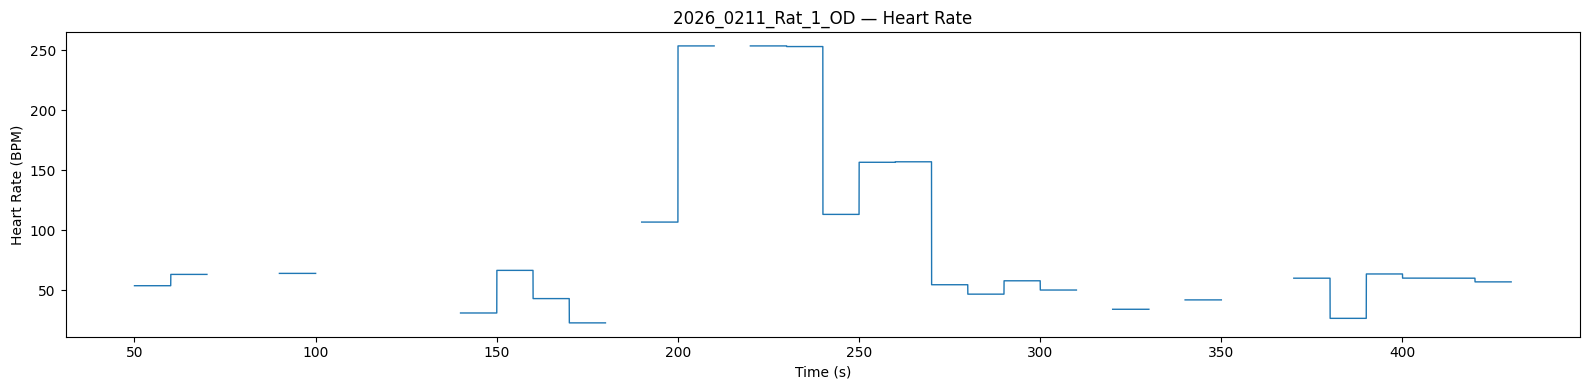

In [8]:
# Cell 8: HR 그래프
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(time_data, hr_data, linewidth=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Heart Rate (BPM)")
ax.set_title(os.path.basename(INPUT_FILE).replace(".csv", "") + " — Heart Rate")
plt.tight_layout()
plt.show()

In [9]:
# Cell 9: CSV 저장 (입력 파일과 같은 폴더, 첫 열=time, 두 번째 열=heart_rate)
out_path = os.path.join(
    os.path.dirname(INPUT_FILE),
    os.path.splitext(os.path.basename(INPUT_FILE))[0] + "_hr.csv",
)
pd.DataFrame({"time": time_data, "heart_rate": hr_data}).to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: ../data/2026_0211\2026_0211_Rat_1_OD_hr.csv
